# N07 - Heisenberg-Langevin, Liouville-Space, and Dynamical-Map Methods
## Drift, noise completion, Gaussian channels, input-output fields, and the memory boundary

A reduced open-system description can be written in several mathematically
different but physically equivalent languages when the same approximations are
used consistently. This notebook develops that equivalence for a linearly coupled
bosonic system and then uses it as a translation guide among

$$
\text{normal modes}
\leftrightarrow
\text{Heisenberg-Langevin equations}
\leftrightarrow
\text{GKLS generators}
\leftrightarrow
\text{Gaussian maps}
\leftrightarrow
\text{Liouville-space propagators}
\leftrightarrow
\text{input-output observables}.
$$

The central lesson is that **damping and quantum noise are one physical
structure**. A deterministic drift matrix is not a complete open-system model:
the omitted noise is what preserves commutators, thermalizes the system, completes
the finite-time channel, and determines emitted fields.

## How this notebook is meant to be used

The companion notebooks are designed to be usable independently of the article.
Each notebook states its physical problem and prerequisites, develops a primary
derivation, implements exact and effective models, compares reconstructed and
incomplete predictions, tests convergence and failure, and explains how the
workflow can be adapted to a related model. The article supplies the shared
conceptual synthesis, whereas the notebooks provide a slower computational route
through selected problems.

N07 is a **reference notebook**. It is intended to be reused whenever
one needs to translate between a Hamiltonian reduction and a physical open-system
prediction.

### Prerequisites

The notebook assumes standard operator algebra, density matrices, harmonic
oscillators, and elementary open-system notation. Familiarity with covariance
matrices is useful but not required; the conventions are introduced before use.
Basic Python familiarity is sufficient. QuTiP is used directly for Hilbert-space
operators, master equations, Liouvillians, steady states, vectorization, and Choi
operators.

## Learning goals

After completing N07, the reader should be able to:

1. derive the drift matrix of a damped linear quantum system;
2. perform the small normal-mode rotation and identify its local control
   parameter;
3. derive the finite-time Gaussian channel $X(t),Y(t)$;
4. explain why deterministic damping without input noise is unphysical;
5. verify a Langevin prediction against a QuTiP master equation;
6. reconstruct an experimentally accessible output flux;
7. translate a fast-mode susceptibility into coherent response, dissipation,
   initial layers, and memory kernels;
8. use Liouville-space vectorization, Choi operators, steady states, and gaps;
9. distinguish **physicality** of an approximate map from **accuracy** relative
   to a microscopic model;
10. identify the colored-noise/non-Markovian regime in which a time-local
    white-noise description must be enlarged rather than merely corrected.

## Literature context

The input-output construction follows the quantum stochastic framework of
Gardiner and Collett. The relation between fast-sector elimination and
Liouvillian/non-Hermitian resolvents connects to effective-operator and
dissipative Schrieffer-Wolff methods. Gaussian channels provide the natural
finite-time language for linear bosonic networks, while pseudomode constructions
show how a structured environment can often be represented by enlarging the
system with one or more damped auxiliary modes.

The notebook therefore treats the Markovian Langevin equation and a GKLS master
equation as complementary representations of the **same approximation**, not as
competing theories.

## Canonical manuscript-scale figure

The canonical overview figure below fixes the compact physical story for N07:

- normal-mode hybridization;
- damped energy exchange;
- emitted output flux;
- thermalization completed by quantum noise.

Section 6 regenerates this four-panel figure from the validated calculations
and updates the preview here with the standardized typography and 150 mm width. Abstract physicality tests such as Choi eigenvalues remain
notebook-only diagnostics.

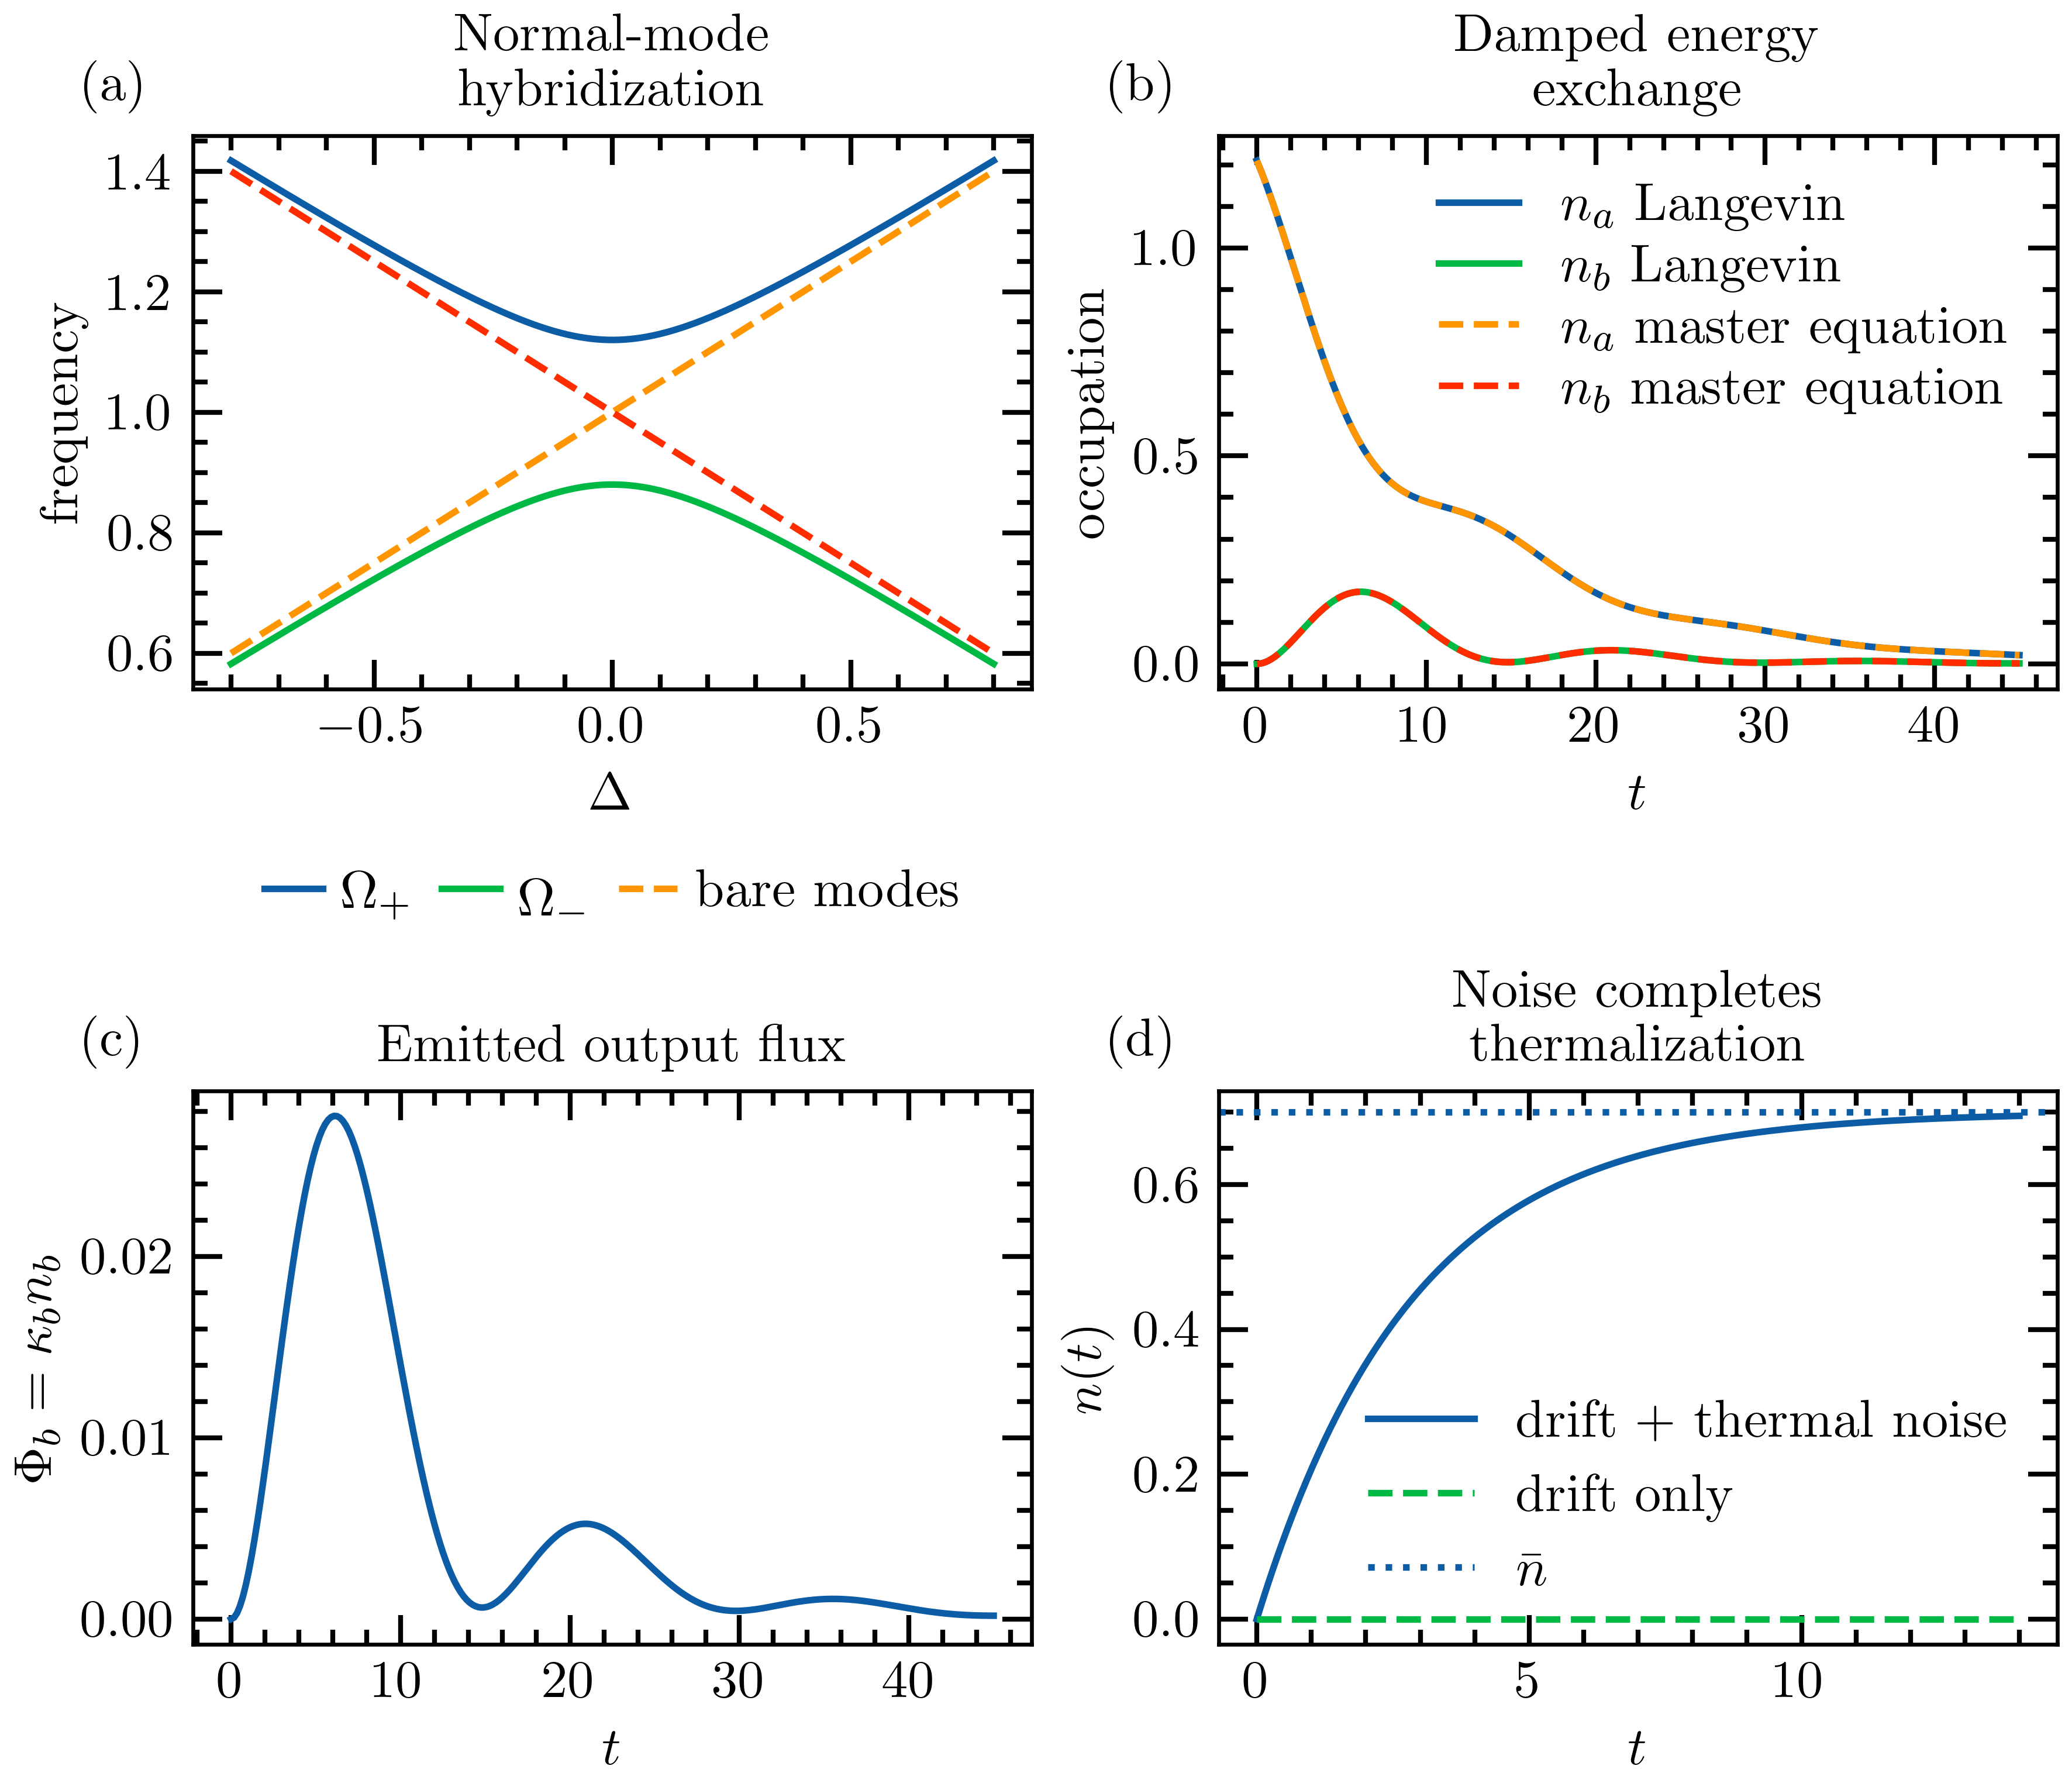

In [1]:
from IPython.display import Image, display

overview_display = display(
    "Run Section 6 to generate the standardized 150 mm overview.",
    display_id=True,
)


## 1. Conventions and computational setup

We use the standard QuTiP dissipator convention

$$
\mathcal D[L]\rho
=
L\rho L^\dagger
-\frac12\{L^\dagger L,\rho\}.
$$

For a damped mode,
$$
\dot\rho
=
-i[H,\rho]
+
\kappa(\bar n+1)\mathcal D[a]\rho
+
\kappa\bar n\,\mathcal D[a^\dagger]\rho.
$$

The corresponding field amplitude decays at $\kappa/2$, while the energy
relaxation rate is $\kappa$.

Quadratures are
$$
x=\frac{a+a^\dagger}{\sqrt2},
\qquad
p=\frac{a-a^\dagger}{i\sqrt2},
$$
so that $[x,p]=i$. The covariance convention is
$$
V_{jk}
=
\frac12\langle
\Delta r_j\Delta r_k+\Delta r_k\Delta r_j
\rangle.
$$
### Plotting standard (matched to N08)

All generated figures use the global style from
`N08_Quantum-Rabi-Regime-Map_modified_v7.ipynb`: Computer Modern through LaTeX,
10.95 pt text (titles, axis labels, ticks, legends, and panel labels), 1.35 pt
curves, 0.8 pt axes, and a total width of 150 mm. PDF and PNG exports use
600 dpi; their full canvas is saved without tight cropping to preserve that
width (PNG dimensions are rounded to whole pixels).

As in the reference notebook, text rendering requires a working LaTeX
installation with `amsmath` and `dvipng`, in addition to SciencePlots.
Run all cells to regenerate the figures and the opening overview in this style.


In [2]:
from pathlib import Path
import json
import logging
import platform
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
from scipy.linalg import expm, solve_continuous_lyapunov

import qutip as qt
from qutip import (
    Qobj,
    basis,
    coherent,
    destroy,
    expect,
    ket2dm,
    liouvillian,
    mesolve,
    operator_to_vector,
    qeye,
    sigmam,
    sigmap,
    sigmaz,
    steadystate,
    tensor,
    thermal_dm,
    to_choi,
    tracedist,
)

logging.getLogger("fontTools.ttLib.tables._h_e_a_d").setLevel(logging.ERROR)

plt.style.use(["science", "notebook"])

# Figure typography and geometry for a 150 mm manuscript column.
# Matplotlib ships cmr10, which closely matches the Computer Modern family
# used by the default LaTeX ``article`` class.
FIG_WIDTH_150MM = 150.0 / 25.4
SCIPOST_FONT_SIZE = 10.95  # LaTeX article class with option 11pt
CURVE_LINEWIDTH = 1.35
EXPORT_DPI = 600
plt.rcParams.update({
    # Figure
    "figure.dpi": 150,
    "figure.figsize": (FIG_WIDTH_150MM, 3.25),
    "savefig.bbox": None,  # Preserve the physical 150 mm page width.
    "savefig.dpi": EXPORT_DPI,

    # Let LaTeX render both text and mathematics
    "text.usetex": True,

    # SciPost.cls -> article[11pt] -> default Computer Modern
    "font.family": "serif",

    # Match LaTeX's \normalsize for article[11pt]
    "font.size": SCIPOST_FONT_SIZE,
    "axes.labelsize": SCIPOST_FONT_SIZE,
    "axes.titlesize": SCIPOST_FONT_SIZE,
    "legend.fontsize": SCIPOST_FONT_SIZE,
    "xtick.labelsize": SCIPOST_FONT_SIZE,
    "ytick.labelsize": SCIPOST_FONT_SIZE,

    # Plot styling
    "axes.linewidth": 0.8,
    "lines.linewidth": CURVE_LINEWIDTH,
    "lines.markersize": 4.2,

    # Same math packages loaded/compatible with SciPost
    "text.latex.preamble": r"\usepackage{amsmath}",
})

ROOT = Path.cwd()
FIG_MANUSCRIPT = ROOT / "figures" / "manuscript"
FIG_NOTEBOOK = ROOT / "figures" / "notebook"
DATA_DIR = ROOT / "data"
for directory in (FIG_MANUSCRIPT, FIG_NOTEBOOK, DATA_DIR):
    directory.mkdir(parents=True, exist_ok=True)

SOLVER = {
    "method": "bdf",
    "atol": 1e-10,
    "rtol": 1e-8,
    "nsteps": 30000,
    "store_states": True,
    "progress_bar": False,
}

def save_figure(fig, stem, manuscript=False):
    """Export the complete 150 mm canvas without changing text or line sizes."""
    target = FIG_MANUSCRIPT if manuscript else FIG_NOTEBOOK
    fig.set_size_inches(FIG_WIDTH_150MM, fig.get_figheight(), forward=True)
    # Tight cropping changes the final page width. Constrained layout already
    # reserves space for titles, legends, labels, and panel letters.
    with plt.rc_context({"savefig.bbox": None}):
        for suffix in ("pdf", "png"):
            fig.savefig(
                target / f"{stem}.{suffix}",
                dpi=EXPORT_DPI,
                bbox_inches=None,
            )


def panel_label(ax, label):
    ax.text(
        -0.13, 1.04, f"({label})", transform=ax.transAxes,
        fontsize=SCIPOST_FONT_SIZE, fontweight="bold", va="bottom", ha="left",
    )


def save_table(frame, stem):
    frame.to_csv(DATA_DIR / f"{stem}.csv", index=False)

def quadrature_matrices(omega_a, omega_b, coupling, kappa_a, kappa_b, nbar_a, nbar_b):
    Hq = np.array([
        [omega_a, 0.0, coupling, 0.0],
        [0.0, omega_a, 0.0, coupling],
        [coupling, 0.0, omega_b, 0.0],
        [0.0, coupling, 0.0, omega_b],
    ], dtype=float)

    Omega = np.array([
        [0.0, 1.0, 0.0, 0.0],
        [-1.0, 0.0, 0.0, 0.0],
        [0.0, 0.0, 0.0, 1.0],
        [0.0, 0.0, -1.0, 0.0],
    ], dtype=float)

    damping = 0.5 * np.diag([kappa_a, kappa_a, kappa_b, kappa_b])
    A = Omega @ Hq - damping
    D = np.diag([
        kappa_a * (nbar_a + 0.5),
        kappa_a * (nbar_a + 0.5),
        kappa_b * (nbar_b + 0.5),
        kappa_b * (nbar_b + 0.5),
    ])
    return A, D, Omega

def gaussian_channel_trajectory(A, D, r0, V0, times):
    # For a stable drift matrix, V_inf solves
    # A V_inf + V_inf A^T + D = 0.
    V_inf = solve_continuous_lyapunov(A, -D)

    means = []
    covariances = []
    X_list = []
    Y_list = []

    for time in times:
        X = expm(A * time)
        Y = V_inf - X @ V_inf @ X.T
        r = X @ r0
        V = X @ V0 @ X.T + Y

        X_list.append(X)
        Y_list.append(Y)
        means.append(r)
        covariances.append(V)

    return (
        np.asarray(means),
        np.asarray(covariances),
        np.asarray(X_list),
        np.asarray(Y_list),
        V_inf,
    )

def occupations_from_gaussian(means, covariances):
    na = 0.5 * (
        covariances[:, 0, 0]
        + covariances[:, 1, 1]
        + means[:, 0]**2
        + means[:, 1]**2
        - 1.0
    )
    nb = 0.5 * (
        covariances[:, 2, 2]
        + covariances[:, 3, 3]
        + means[:, 2]**2
        + means[:, 3]**2
        - 1.0
    )
    return na, nb

def two_mode_qutip_model(
    cutoff,
    omega_a,
    omega_b,
    coupling,
    kappa_a,
    kappa_b,
    nbar_a=0.0,
    nbar_b=0.0,
):
    a = tensor(destroy(cutoff), qeye(cutoff))
    b = tensor(qeye(cutoff), destroy(cutoff))

    H = (
        omega_a * a.dag() * a
        + omega_b * b.dag() * b
        + coupling * (a.dag() * b + a * b.dag())
    )

    c_ops = [
        np.sqrt(kappa_a * (nbar_a + 1.0)) * a,
        np.sqrt(kappa_b * (nbar_b + 1.0)) * b,
    ]
    if nbar_a > 0.0:
        c_ops.append(np.sqrt(kappa_a * nbar_a) * a.dag())
    if nbar_b > 0.0:
        c_ops.append(np.sqrt(kappa_b * nbar_b) * b.dag())

    return H, c_ops, a, b

def two_mode_master_occupations(
    cutoff,
    omega_a,
    omega_b,
    coupling,
    kappa_a,
    kappa_b,
    nbar_a,
    nbar_b,
    alpha,
    times,
):
    H, c_ops, a, b = two_mode_qutip_model(
        cutoff,
        omega_a,
        omega_b,
        coupling,
        kappa_a,
        kappa_b,
        nbar_a,
        nbar_b,
    )

    psi0 = tensor(coherent(cutoff, alpha), basis(cutoff, 0))
    out = mesolve(
        H,
        psi0,
        times,
        c_ops=c_ops,
        e_ops=[a.dag() * a, b.dag() * b],
        options=SOLVER,
    )
    return np.asarray(out.expect[0], dtype=float), np.asarray(out.expect[1], dtype=float)

print(f"Python      : {platform.python_version()}")
print(f"QuTiP       : {qt.__version__}")
print(f"NumPy       : {np.__version__}")
print(f"SciencePlots: installed")

Python      : 3.11.9
QuTiP       : 5.2.0
NumPy       : 2.3.2
SciencePlots: installed


## 2. Physical benchmark: two linearly coupled damped modes

The coherent Hamiltonian is

$$
H
=
\omega_a a^\dagger a
+
\omega_b b^\dagger b
+
G(a^\dagger b+ab^\dagger).
$$

The Heisenberg-Langevin equation for
$$
\mathbf v=(a,b)^T
$$
has deterministic drift

$$
\dot{\mathbf v}
=
M\mathbf v
+
B\mathbf v_{\rm in},
$$

with

$$
M
=
-i
\begin{pmatrix}
\omega_a&G\\
G&\omega_b
\end{pmatrix}
-
\frac12
\begin{pmatrix}
\kappa_a&0\\
0&\kappa_b
\end{pmatrix}.
$$

The noise matrix $B$ and the input correlations are not optional decorations:
they complete the physical channel generated by the drift.

## 3. Operational first method: small normal-mode rotation

For detuning
$$
\Delta=\omega_a-\omega_b,
$$
use
$$
S=\theta(a^\dagger b-ab^\dagger),
\qquad
\theta\simeq\frac{G}{\Delta}.
$$

To second order,

$$
\widetilde H
\simeq
\left(
\omega_a+\frac{G^2}{\Delta}
\right)a^\dagger a
+
\left(
\omega_b-\frac{G^2}{\Delta}
\right)b^\dagger b.
$$

The exact angle satisfies

$$
\tan(2\theta_{\rm ex})=\frac{2G}{\Delta},
$$

and the exact frequencies are

$$
\Omega_\pm
=
\frac{\omega_a+\omega_b}{2}
\pm
\frac12\sqrt{\Delta^2+4G^2}.
$$

The local control parameter is therefore not simply $G$, but

$$
\boxed{
\eta_{\rm mix}=\left|\frac{G}{\Delta}\right|.
}
$$

This coherent rotation is only the first step. In an open system, the bath
couplings, input noise, and output operators must be transformed consistently as
well.

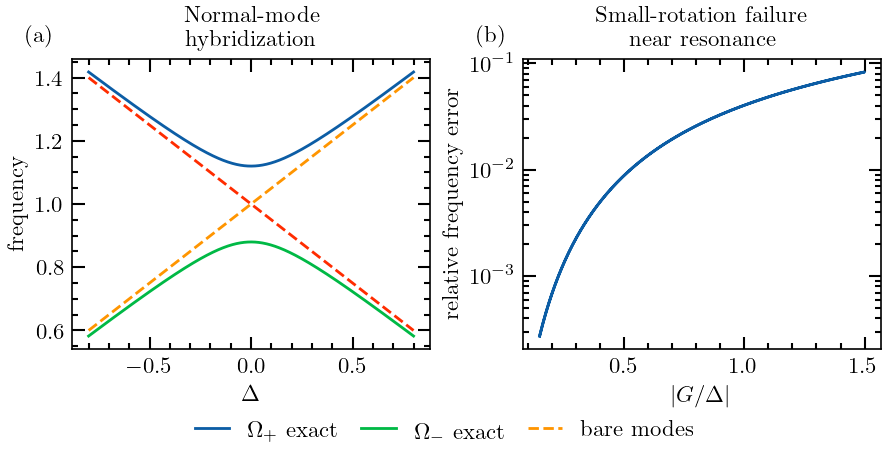

In [3]:
G_ROT = 0.12
detuning_scan = np.linspace(-0.8, 0.8, 801)
mask = np.abs(detuning_scan) > 0.08

omega_center = 1.0
omega_a_scan = omega_center + 0.5 * detuning_scan
omega_b_scan = omega_center - 0.5 * detuning_scan

omega_plus_exact = omega_center + 0.5 * np.sqrt(detuning_scan**2 + 4 * G_ROT**2)
omega_minus_exact = omega_center - 0.5 * np.sqrt(detuning_scan**2 + 4 * G_ROT**2)

omega_a_pert = omega_a_scan.copy()
omega_b_pert = omega_b_scan.copy()
omega_a_pert[mask] += G_ROT**2 / detuning_scan[mask]
omega_b_pert[mask] -= G_ROT**2 / detuning_scan[mask]

# Match perturbative branches continuously to the exact upper/lower branches
# away from the singular resonant point.
upper_pert = np.where(detuning_scan >= 0, omega_a_pert, omega_b_pert)
lower_pert = np.where(detuning_scan >= 0, omega_b_pert, omega_a_pert)

rotation_table = pd.DataFrame({
    "detuning": detuning_scan[mask],
    "eta_mix": np.abs(G_ROT / detuning_scan[mask]),
    "upper_exact": omega_plus_exact[mask],
    "lower_exact": omega_minus_exact[mask],
    "upper_perturbative": upper_pert[mask],
    "lower_perturbative": lower_pert[mask],
})
save_table(rotation_table, "N07_D1")

fig, axes = plt.subplots(1, 2, figsize=(FIG_WIDTH_150MM, 3.1), constrained_layout=True)

axes[0].plot(detuning_scan, omega_plus_exact, label=r"$\Omega_+$ exact")
axes[0].plot(detuning_scan, omega_minus_exact, label=r"$\Omega_-$ exact")
axes[0].plot(detuning_scan, omega_a_scan, "--", linewidth=CURVE_LINEWIDTH, label="bare modes")
axes[0].plot(detuning_scan, omega_b_scan, "--", linewidth=CURVE_LINEWIDTH)
axes[0].set(
    xlabel=r"$\Delta$",
    ylabel="frequency",
    title="Normal-mode\nhybridization",
)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc="outside lower center", frameon=False,
    ncol=3, handlelength=1.5, columnspacing=1.0,
)

upper_rel_error = np.abs(
    rotation_table["upper_perturbative"]
    - rotation_table["upper_exact"]
) / rotation_table["upper_exact"]

axes[1].semilogy(rotation_table["eta_mix"], upper_rel_error)
axes[1].set(
    xlabel=r"$|G/\Delta|$",
    ylabel="relative frequency error",
    title="Small-rotation failure\nnear resonance",
)

for label, ax in zip("ab", axes):
    panel_label(ax, label)

save_figure(fig, "N07_F1")
plt.show()

**Figure N07_F1.** The perturbative normal-mode rotation is controlled away from
the hybridization region and fails as $|G/\Delta|$ becomes large. The correct
repair at resonance is to retain both hybridized modes rather than push the same
off-resonant expansion to higher order.

## 4. Complete Langevin and Gaussian-map description

For quadratures
$$
\mathbf r=(x_a,p_a,x_b,p_b)^T,
$$
the first moments obey
$$
\dot{\langle\mathbf r\rangle}=A\langle\mathbf r\rangle,
$$
and the covariance matrix obeys
$$
\dot V=AV+VA^T+D.
$$

The finite-time Gaussian channel is
$$
\langle\mathbf r(t)\rangle
=
X(t)\langle\mathbf r(0)\rangle,
$$
$$
V(t)
=
X(t)V(0)X^T(t)+Y(t),
$$
with
$$
X(t)=e^{At},
\qquad
Y(t)
=
\int_0^t
e^{As}D e^{A^Ts}\,ds.
$$

For a stable $A$, if $V_\infty$ satisfies
$$
AV_\infty+V_\infty A^T+D=0,
$$
then
$$
Y(t)
=
V_\infty-X(t)V_\infty X^T(t).
$$

This is an exact finite-time description of the linear Markovian model, not a
separate approximation.

In [4]:
# Same physical benchmark used by the recovered manuscript-scale figure.
omega_a = 1.35
omega_b = 1.00
G = 0.12
kappa_a = 0.08
kappa_b = 0.16
nbar_a = 0.0
nbar_b = 0.0
alpha = 1.1
times = np.linspace(0.0, 45.0, 260)

A, D, Omega = quadrature_matrices(
    omega_a,
    omega_b,
    G,
    kappa_a,
    kappa_b,
    nbar_a,
    nbar_b,
)

r0 = np.array([np.sqrt(2.0) * alpha, 0.0, 0.0, 0.0])
V0 = 0.5 * np.eye(4)

means, covariances, X_list, Y_list, V_inf = gaussian_channel_trajectory(
    A, D, r0, V0, times
)
na_gaussian, nb_gaussian = occupations_from_gaussian(means, covariances)

na_master, nb_master = two_mode_master_occupations(
    8,
    omega_a,
    omega_b,
    G,
    kappa_a,
    kappa_b,
    nbar_a,
    nbar_b,
    alpha,
    times,
)

gaussian_master_error = max(
    np.max(np.abs(na_gaussian - na_master)),
    np.max(np.abs(nb_gaussian - nb_master)),
)

uncertainty_minimum = min(
    np.min(np.linalg.eigvalsh(V + 0.5j * Omega))
    for V in covariances
)

drift_stability = np.max(np.real(np.linalg.eigvals(A)))
output_flux = kappa_b * nb_gaussian

benchmark_summary = pd.DataFrame({
    "quantity": [
        "largest_real_drift_eigenvalue",
        "gaussian_master_max_occupation_difference",
        "minimum_uncertainty_matrix_eigenvalue",
        "maximum_output_flux",
        "gaussian_initial_occupation_a",
        "master_initial_occupation_a",
    ],
    "value": [
        drift_stability,
        gaussian_master_error,
        uncertainty_minimum,
        np.max(output_flux),
        na_gaussian[0],
        na_master[0],
    ],
})
save_table(benchmark_summary, "N07_D2")

benchmark_dynamics = pd.DataFrame({
    "t": times,
    "n_a_gaussian": na_gaussian,
    "n_b_gaussian": nb_gaussian,
    "n_a_master": na_master,
    "n_b_master": nb_master,
    "output_flux_b": output_flux,
})
save_table(benchmark_dynamics, "N07_D3")

benchmark_summary

,quantity,value
0,largest_real_drift_eigenvalue,-4.348208e-02
1,gaussian_master_max_occupation_difference,2.910873e-05
2,minimum_uncertainty_matrix_eigenvalue,-5.828671e-16
3,maximum_output_flux,2.774353e-02
4,gaussian_initial_occupation_a,1.210000e+00
5,master_initial_occupation_a,1.209971e+00


The Gaussian channel and the truncated QuTiP master equation describe the same
Markovian model in two representations. Their discrepancy is therefore a
**numerical-reference error**, dominated here by the finite Fock cutoff, not an
effective-model error.

## 5. Fock-cutoff convergence

A Gaussian calculation has no Fock truncation. The QuTiP density-matrix reference
does. The cutoff must therefore be increased until its numerical error lies below
the physical discrepancy one intends to interpret.

The benchmark uses a coherent initial state with
$$
|\alpha|^2=1.21.
$$
We compare several cutoffs to a larger reference calculation.

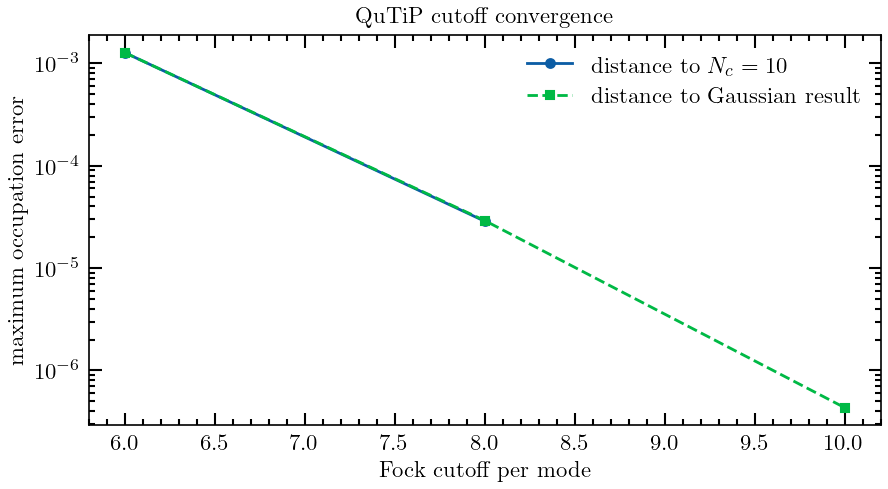

,cutoff,max_error_to_N10,max_error_to_gaussian
0,6,0.001273,1.273644e-03
1,8,0.000029,2.910873e-05
2,10,0.000000,4.328004e-07


In [5]:
cutoffs = [6, 8, 10]
cutoff_runs = {}

for cutoff in cutoffs:
    cutoff_runs[cutoff] = two_mode_master_occupations(
        cutoff,
        omega_a,
        omega_b,
        G,
        kappa_a,
        kappa_b,
        nbar_a,
        nbar_b,
        alpha,
        times,
    )

na_ref, nb_ref = cutoff_runs[10]
cutoff_rows = []
for cutoff in cutoffs:
    na_cut, nb_cut = cutoff_runs[cutoff]
    cutoff_rows.append({
        "cutoff": cutoff,
        "max_error_to_N10": max(
            np.max(np.abs(na_cut - na_ref)),
            np.max(np.abs(nb_cut - nb_ref)),
        ),
        "max_error_to_gaussian": max(
            np.max(np.abs(na_cut - na_gaussian)),
            np.max(np.abs(nb_cut - nb_gaussian)),
        ),
    })

cutoff_table = pd.DataFrame(cutoff_rows)
save_table(cutoff_table, "N07_D4")

fig, ax = plt.subplots(figsize=(FIG_WIDTH_150MM, 3.25), constrained_layout=True)
comparison = cutoff_table.iloc[:-1]
ax.semilogy(
    comparison["cutoff"],
    comparison["max_error_to_N10"],
    "o-",
    label=r"distance to $N_c=10$",
)
ax.semilogy(
    cutoff_table["cutoff"],
    cutoff_table["max_error_to_gaussian"],
    "s--",
    label="distance to Gaussian result",
)
ax.set(
    xlabel="Fock cutoff per mode",
    ylabel="maximum occupation error",
    title="QuTiP cutoff convergence",
)
ax.legend(frameon=False)
save_figure(fig, "N07_F2")
plt.show()

cutoff_table

## 6. Manuscript-scale physical validation

The output-field convention is

$$
b_{\rm out}(t)
=
b_{\rm in}(t)-\sqrt{\kappa_b}\,b(t).
$$

For vacuum input and normally ordered photon flux,

$$
\Phi_b(t)
=
\kappa_b\langle b^\dagger b\rangle(t).
$$

The four panels below use directly interpretable physical quantities. Choi,
Kossakowski, uncertainty, and trace-distance diagnostics are intentionally kept
outside the manuscript-scale figure.

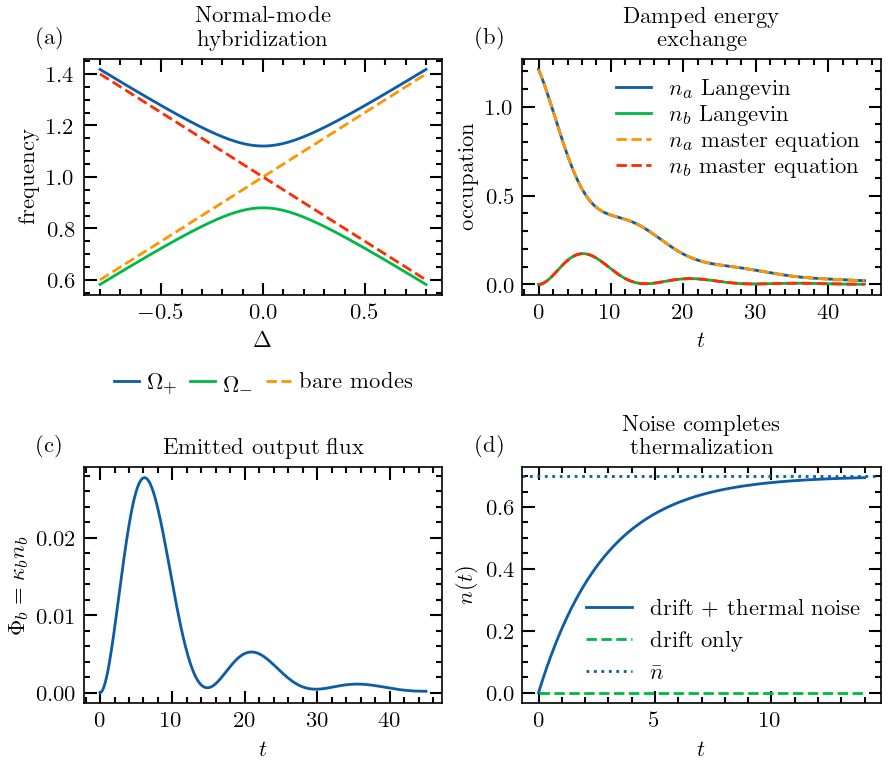

In [6]:
# Normal-mode frequencies for the manuscript panel.
detuning_mf = np.linspace(-0.8, 0.8, 400)
omega_a_bare = 1.0 + 0.5 * detuning_mf
omega_b_bare = 1.0 - 0.5 * detuning_mf
omega_plus = 1.0 + 0.5 * np.sqrt(detuning_mf**2 + 4 * G**2)
omega_minus = 1.0 - 0.5 * np.sqrt(detuning_mf**2 + 4 * G**2)

# Thermalization demonstration.
kappa_th = 0.35
nbar_th = 0.7
n0_th = 0.0
times_th = np.linspace(0.0, 14.0, 400)
thermal_complete = (
    n0_th * np.exp(-kappa_th * times_th)
    + nbar_th * (1.0 - np.exp(-kappa_th * times_th))
)
thermal_drift_only = n0_th * np.exp(-kappa_th * times_th)

thermal_table = pd.DataFrame({
    "t": times_th,
    "drift_plus_noise": thermal_complete,
    "drift_only": thermal_drift_only,
    "thermal_target": np.full_like(times_th, nbar_th),
})
save_table(thermal_table, "N07_D5")

fig, axes = plt.subplots(2, 2, figsize=(FIG_WIDTH_150MM, 5.1), constrained_layout=True)

ax = axes[0, 0]
ax.plot(detuning_mf, omega_plus, label=r"$\Omega_+$")
ax.plot(detuning_mf, omega_minus, label=r"$\Omega_-$")
ax.plot(detuning_mf, omega_a_bare, "--", linewidth=CURVE_LINEWIDTH, label="bare modes")
ax.plot(detuning_mf, omega_b_bare, "--", linewidth=CURVE_LINEWIDTH)
ax.set(
    xlabel=r"$\Delta$",
    ylabel="frequency",
    title="Normal-mode\nhybridization",
)
ax.legend(
    frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.24),
    ncol=3, handlelength=1.1, handletextpad=0.35, columnspacing=0.55,
)

ax = axes[0, 1]
ax.plot(times, na_gaussian, label=r"$n_a$ Langevin")
ax.plot(times, nb_gaussian, label=r"$n_b$ Langevin")
ax.plot(times, na_master, "--", label=r"$n_a$ master equation")
ax.plot(times, nb_master, "--", label=r"$n_b$ master equation")
ax.set(
    xlabel=r"$t$",
    ylabel="occupation",
    title="Damped energy\nexchange",
)
ax.legend(frameon=False, ncol=1, handlelength=1.5, labelspacing=0.25)

ax = axes[1, 0]
ax.plot(times, output_flux)
ax.set(
    xlabel=r"$t$",
    ylabel=r"$\Phi_b=\kappa_b n_b$",
    title="Emitted output flux",
)

ax = axes[1, 1]
ax.plot(times_th, thermal_complete, label="drift + thermal noise")
ax.plot(times_th, thermal_drift_only, "--", label="drift only")
ax.axhline(nbar_th, linestyle=":", linewidth=CURVE_LINEWIDTH, label=r"$\bar n$")
ax.set(
    xlabel=r"$t$",
    ylabel=r"$n(t)$",
    title="Noise completes\nthermalization",
)
ax.legend(frameon=False, loc="lower right")

for label, ax in zip("abcd", axes.flat):
    panel_label(ax, label)

save_figure(fig, "N07_F11")
if globals().get("overview_display") is not None:
    overview_display.update(Image(
        filename=str(FIG_NOTEBOOK / "N07_F11.png"),
        width=round(FIG_WIDTH_150MM * plt.rcParams["figure.dpi"]),
    ))
plt.show()

**Notebook Figure N07_F11.**  
(a) Exact normal-mode hybridization.  
(b) Damped energy exchange from the Gaussian/Langevin and QuTiP master-equation
descriptions.  
(c) Emitted output flux through mode $b$.  
(d) Thermalization with and without the input-noise contribution.

Panels (b) and (d) make the central physical point: damping without the
corresponding noise is not a complete open-system prediction.

## 7. Why quantum noise cannot be omitted

For a single damped mode, deterministic drift alone gives

$$
\dot a=-\frac{\kappa}{2}a,
\qquad
a(t)=e^{-\kappa t/2}a(0).
$$

Then

$$
[a(t),a^\dagger(t)]
=
e^{-\kappa t},
$$

which violates the canonical commutation relation.

The full Langevin solution contains the integrated input field,

$$
a(t)
=
e^{-\kappa t/2}a(0)
-
\sqrt{\kappa}
\int_0^t
e^{-\kappa(t-s)/2}a_{\rm in}(s)\,ds.
$$

For vacuum white noise, the second term contributes exactly
$1-e^{-\kappa t}$ to the commutator.

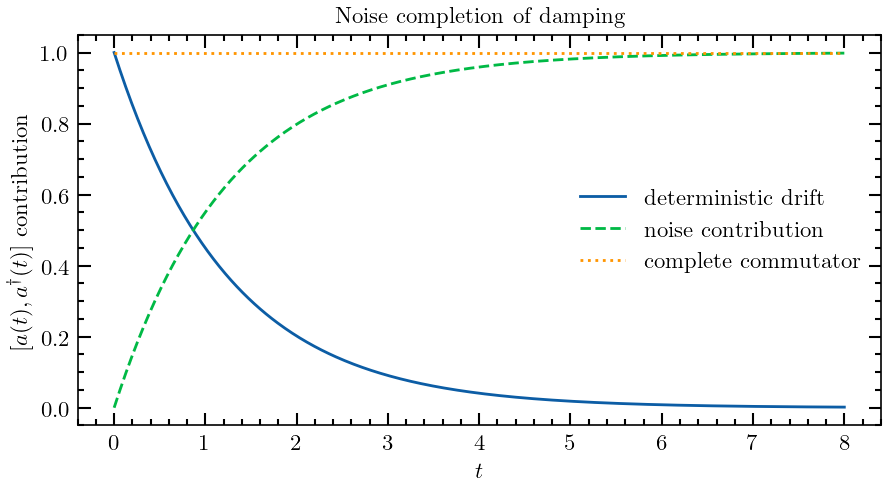

In [7]:
kappa_comm = 0.8
t_comm = np.linspace(0.0, 8.0, 501)

comm_drift = np.exp(-kappa_comm * t_comm)
comm_noise = 1.0 - np.exp(-kappa_comm * t_comm)
comm_complete = comm_drift + comm_noise

commutator_table = pd.DataFrame({
    "t": t_comm,
    "drift_contribution": comm_drift,
    "noise_contribution": comm_noise,
    "complete_commutator": comm_complete,
})
save_table(commutator_table, "N07_D6")

fig, ax = plt.subplots(figsize=(FIG_WIDTH_150MM, 3.25), constrained_layout=True)
ax.plot(t_comm, comm_drift, label="deterministic drift")
ax.plot(t_comm, comm_noise, "--", label="noise contribution")
ax.plot(t_comm, comm_complete, ":", label="complete commutator")
ax.set(
    xlabel=r"$t$",
    ylabel=r"$[a(t),a^\dagger(t)]$ contribution",
    title="Noise completion of damping",
)
ax.legend(frameon=False)
save_figure(fig, "N07_F3")
plt.show()

This operator-level failure is the same logical mistake as retaining a
non-Hermitian conditional drift while discarding the recycling process that
completes an unconditional master equation.

## 8. Finite-time Gaussian-channel physicality

For the convention $[r_j,r_k]=i\Omega_{jk}$, a Gaussian map
$$
V\mapsto XVX^T+Y
$$
is completely positive when

$$
\boxed{
Y+\frac{i}{2}
\left(
\Omega-X\Omega X^T
\right)
\succeq0.
}
$$

The state covariance must separately obey the uncertainty condition

$$
V+\frac{i}{2}\Omega\succeq0.
$$

These tests establish physicality of the Gaussian map. They do not establish
agreement with a microscopic model.

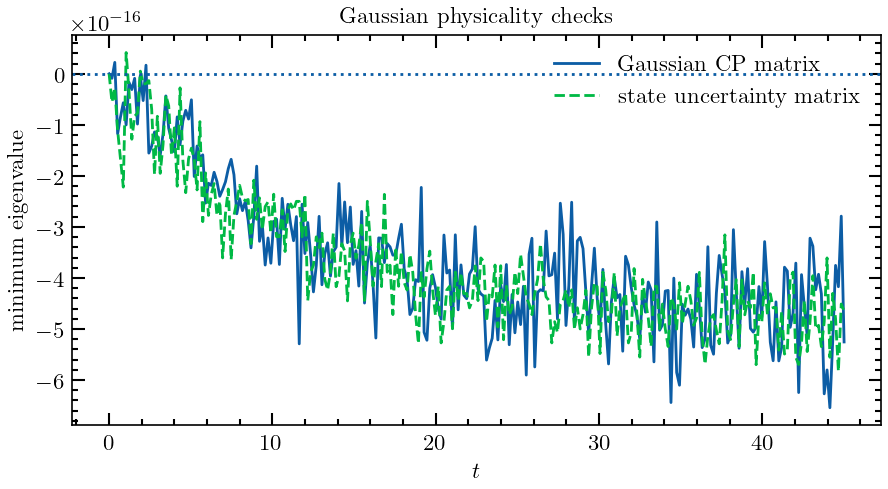

In [8]:
gaussian_cp_rows = []

for time, X, Y, V in zip(times, X_list, Y_list, covariances):
    cp_matrix = Y + 0.5j * (Omega - X @ Omega @ X.T)
    uncertainty_matrix = V + 0.5j * Omega

    gaussian_cp_rows.append({
        "t": time,
        "minimum_gaussian_cp_eigenvalue": np.min(np.linalg.eigvalsh(cp_matrix)),
        "minimum_uncertainty_eigenvalue": np.min(np.linalg.eigvalsh(uncertainty_matrix)),
    })

gaussian_cp_table = pd.DataFrame(gaussian_cp_rows)
save_table(gaussian_cp_table, "N07_D7")

fig, ax = plt.subplots(figsize=(FIG_WIDTH_150MM, 3.25), constrained_layout=True)
ax.plot(
    gaussian_cp_table["t"],
    gaussian_cp_table["minimum_gaussian_cp_eigenvalue"],
    label="Gaussian CP matrix",
)
ax.plot(
    gaussian_cp_table["t"],
    gaussian_cp_table["minimum_uncertainty_eigenvalue"],
    "--",
    label="state uncertainty matrix",
)
ax.axhline(0.0, linestyle=":", linewidth=CURVE_LINEWIDTH)
ax.set(
    xlabel=r"$t$",
    ylabel="minimum eigenvalue",
    title="Gaussian physicality checks",
)
ax.legend(frameon=False)
save_figure(fig, "N07_F4")
plt.show()

## 9. Relation to the GKLS master equation

For
$$
\dot\rho
=
-i[H,\rho]
+
\kappa\mathcal D[a]\rho,
$$
the adjoint generator gives

$$
\frac{d}{dt}\langle O\rangle
=
\langle\mathcal L^\dagger O\rangle.
$$

For $O=a$, the deterministic part is
$$
\mathcal L^\dagger a
=
-\left(i\omega_c+\frac{\kappa}{2}\right)a
+\text{drive}.
$$

The explicit Langevin noise is not visible in the equation for the first moment
when the input field has zero mean. It becomes essential for operator products,
thermalization, output fields, spectra, and commutator preservation.

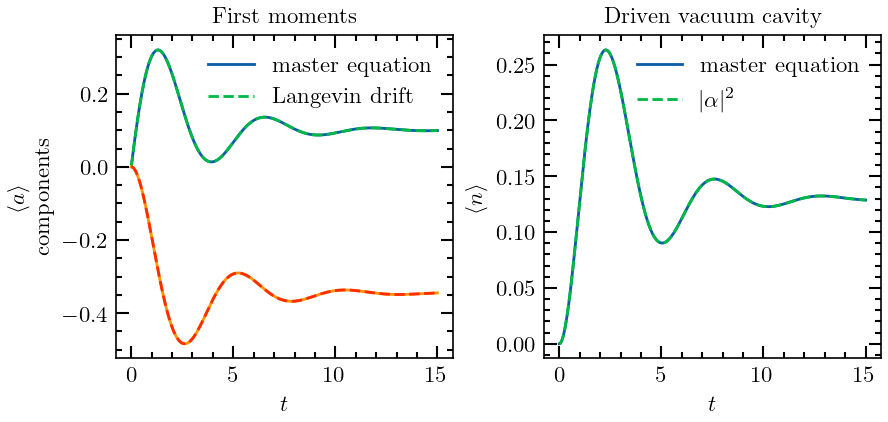

maximum_first_moment_error    9.061600e-08
maximum_occupation_error      6.473267e-08
dtype: float64

In [9]:
cutoff_cavity = 18
a_cavity = destroy(cutoff_cavity)
n_cavity = a_cavity.dag() * a_cavity

omega_c = 1.2
kappa_c = 0.7
drive_c = 0.45

H_cavity = (
    omega_c * n_cavity
    + 1j * drive_c * (a_cavity.dag() - a_cavity)
)
c_ops_cavity = [np.sqrt(kappa_c) * a_cavity]
rho0_cavity = ket2dm(basis(cutoff_cavity, 0))

t_cavity = np.linspace(0.0, 15.0, 801)
out_cavity = mesolve(
    H_cavity,
    rho0_cavity,
    t_cavity,
    c_ops=c_ops_cavity,
    e_ops=[a_cavity, n_cavity],
    options=SOLVER,
)

z_cavity = 1j * omega_c + 0.5 * kappa_c
alpha_analytic = drive_c / z_cavity * (1.0 - np.exp(-z_cavity * t_cavity))

cavity_table = pd.DataFrame({
    "t": t_cavity,
    "Re_alpha_master": np.real(out_cavity.expect[0]),
    "Im_alpha_master": np.imag(out_cavity.expect[0]),
    "Re_alpha_langevin": np.real(alpha_analytic),
    "Im_alpha_langevin": np.imag(alpha_analytic),
    "n_master": np.asarray(out_cavity.expect[1], dtype=float),
    "n_coherent_prediction": np.abs(alpha_analytic)**2,
})
save_table(cavity_table, "N07_D8")

first_moment_error = max(
    np.max(np.abs(cavity_table["Re_alpha_master"] - cavity_table["Re_alpha_langevin"])),
    np.max(np.abs(cavity_table["Im_alpha_master"] - cavity_table["Im_alpha_langevin"])),
)
occupation_error = np.max(
    np.abs(cavity_table["n_master"] - cavity_table["n_coherent_prediction"])
)

fig, axes = plt.subplots(1, 2, figsize=(FIG_WIDTH_150MM, 2.8), constrained_layout=True)

axes[0].plot(t_cavity, cavity_table["Re_alpha_master"], label="master equation")
axes[0].plot(t_cavity, cavity_table["Re_alpha_langevin"], "--", label="Langevin drift")
axes[0].plot(t_cavity, cavity_table["Im_alpha_master"])
axes[0].plot(t_cavity, cavity_table["Im_alpha_langevin"], "--")
axes[0].set(
    xlabel=r"$t$",
    ylabel=r"$\langle a\rangle$" + "\ncomponents",
    title="First moments",
)
axes[0].legend(frameon=False)

axes[1].plot(t_cavity, cavity_table["n_master"], label="master equation")
axes[1].plot(t_cavity, cavity_table["n_coherent_prediction"], "--", label=r"$|\alpha|^2$")
axes[1].set(
    xlabel=r"$t$",
    ylabel=r"$\langle n\rangle$",
    title="Driven vacuum cavity",
)
axes[1].legend(frameon=False)

save_figure(fig, "N07_F5")
plt.show()

pd.Series({
    "maximum_first_moment_error": first_moment_error,
    "maximum_occupation_error": occupation_error,
})

## 10. Exact formal solution, initial layer, and susceptibility

For a fast lossy mediator,

$$
\dot a
=
\left(
i\Delta_c-\frac{\kappa}{2}
\right)a
-iF(t)
-\sqrt\kappa\,a_{\rm in}(t).
$$

The exact formal solution is

$$
a(t)
=
e^{(i\Delta_c-\kappa/2)t}a(0)
-i\int_0^t
e^{(i\Delta_c-\kappa/2)(t-s)}F(s)\,ds
+\text{filtered input noise}.
$$

Three structures are visible immediately:

1. a homogeneous **initial layer**;
2. a retarded deterministic response;
3. filtered quantum noise.

If $F(t)$ varies slowly over the cavity correlation time, the leading local
response is

$$
a(t)
\simeq
\frac{F(t)}{\Delta_c+i\kappa/2}
+\text{noise},
$$

up to the initial layer and derivative corrections.

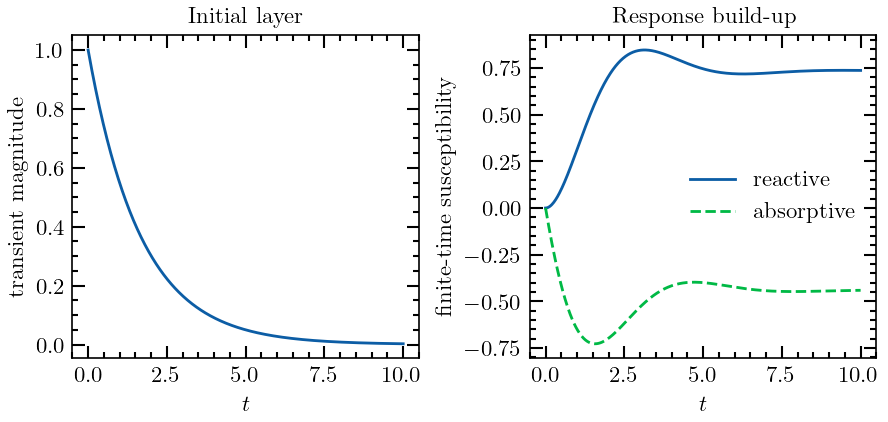

In [10]:
Delta_c = 1.0
kappa_med = 1.2

response_time = np.linspace(0.0, 10.0, 501)
initial_layer = np.exp(
    (1j * Delta_c - 0.5 * kappa_med) * response_time
)
finite_time_response = (
    1.0 - initial_layer
) / (Delta_c + 0.5j * kappa_med)

response_table = pd.DataFrame({
    "t": response_time,
    "initial_layer_abs": np.abs(initial_layer),
    "response_real": np.real(finite_time_response),
    "response_imag": np.imag(finite_time_response),
})
save_table(response_table, "N07_D9")

fig, axes = plt.subplots(1, 2, figsize=(FIG_WIDTH_150MM, 2.8), constrained_layout=True)

axes[0].plot(response_time, np.abs(initial_layer))
axes[0].set(
    xlabel=r"$t$",
    ylabel="transient magnitude",
    title="Initial layer",
)

axes[1].plot(response_time, np.real(finite_time_response), label="reactive")
axes[1].plot(response_time, np.imag(finite_time_response), "--", label="absorptive")
axes[1].set(
    xlabel=r"$t$",
    ylabel="finite-time susceptibility",
    title="Response build-up",
)
axes[1].legend(frameon=False)

save_figure(fig, "N07_F6")
plt.show()

## 11. One complex response: coherent and dissipative sectors

For a Fourier component $F_\omega e^{-i\omega t}$,

$$
\chi_c(\omega)
=
\frac{1}{
-(\Delta_c+\omega)-i\kappa/2
}.
$$

The reactive and absorptive parts of this same response generate coherent and
dissipative reduced terms. For a single slow frequency,

$$
H_{\rm ind}
=
-\operatorname{Re}\chi_c\,F^\dagger F,
\qquad
L_{\rm eff}
=
\sqrt{\kappa}\,\chi_c F
$$

up to an irrelevant phase of the jump.

If
$$
F=\sum_\omega F_\omega,
$$
each Bohr component samples a different susceptibility. Replacing all
$F_\omega$ by one scalar response is justified only when the relevant
frequency spread is small on the scale of the fast response.

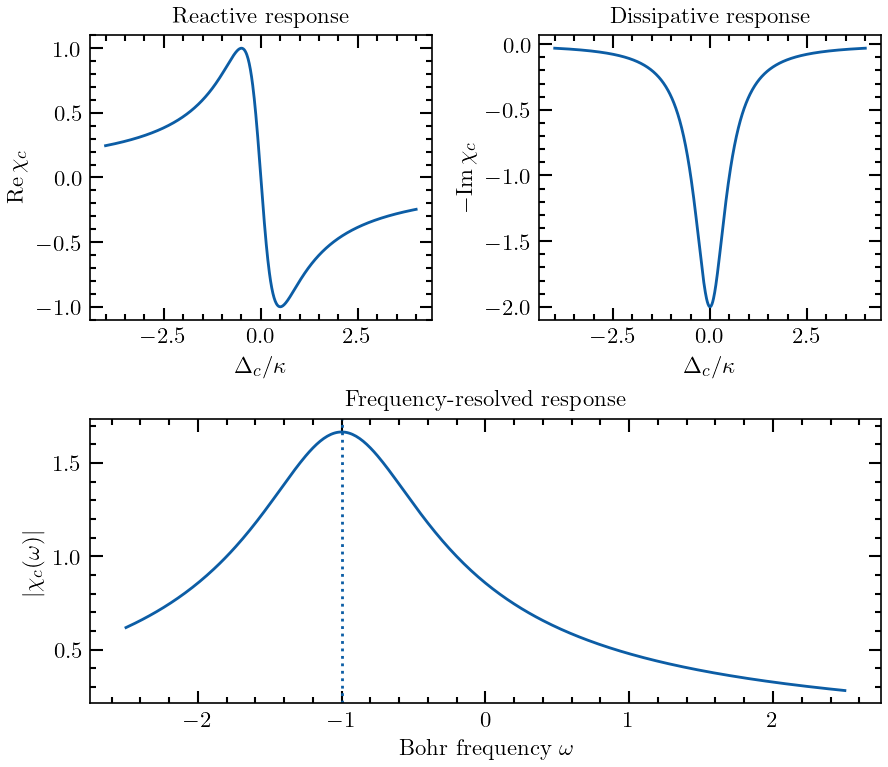

In [11]:
def susceptibility(delta, kappa, frequency=0.0):
    return 1.0 / (-(delta + frequency) - 0.5j * kappa)

delta_response = np.linspace(-4.0, 4.0, 801)
chi_delta = np.array([
    susceptibility(delta, 1.0)
    for delta in delta_response
])

frequency_components = np.linspace(-2.5, 2.5, 401)
chi_frequency = np.array([
    susceptibility(Delta_c, kappa_med, omega)
    for omega in frequency_components
])

susceptibility_table = pd.DataFrame({
    "detuning_over_kappa": delta_response,
    "chi_real": np.real(chi_delta),
    "minus_chi_imag": -np.imag(chi_delta),
})
save_table(susceptibility_table, "N07_D10")

frequency_table = pd.DataFrame({
    "bohr_frequency": frequency_components,
    "chi_abs": np.abs(chi_frequency),
    "chi_real": np.real(chi_frequency),
    "chi_imag": np.imag(chi_frequency),
})
save_table(frequency_table, "N07_D11")

fig = plt.figure(figsize=(FIG_WIDTH_150MM, 5.1), constrained_layout=True)
grid = fig.add_gridspec(2, 2)
axes = [
    fig.add_subplot(grid[0, 0]),
    fig.add_subplot(grid[0, 1]),
    fig.add_subplot(grid[1, :]),
]

axes[0].plot(delta_response, np.real(chi_delta))
axes[0].set(
    xlabel=r"$\Delta_c/\kappa$",
    ylabel=r"$\mathrm{Re}\,\chi_c$",
    title="Reactive response",
)

axes[1].plot(delta_response, -np.imag(chi_delta))
axes[1].set(
    xlabel=r"$\Delta_c/\kappa$",
    ylabel=r"$-\mathrm{Im}\,\chi_c$",
    title="Dissipative response",
)

axes[2].plot(frequency_components, np.abs(chi_frequency))
axes[2].axvline(-Delta_c, linestyle=":", linewidth=CURVE_LINEWIDTH)
axes[2].set(
    xlabel=r"Bohr frequency $\omega$",
    ylabel=r"$|\chi_c(\omega)|$",
    title="Frequency-resolved response",
)

save_figure(fig, "N07_F7")
plt.show()

## 12. Liouvillian resolvents and memory kernels

Projection methods and Langevin response use the same fast-sector information in
different domains. Formally,

$$
\mathcal L_{\rm eff}(z)
=
P\mathcal LP
+
P\mathcal LQ
\frac{1}{z-Q\mathcal LQ}
Q\mathcal LP.
$$

The inverse
$$
(z-Q\mathcal LQ)^{-1}
$$
is the Liouvillian analogue of the susceptibility. In the time domain it becomes
a memory kernel.

For one damped mode,

$$
K(t)
\propto
e^{(i\Delta_c-\kappa/2)t}\Theta(t).
$$

A rapidly decaying kernel supports a local Markovian reduction. A slowly decaying
kernel stores information and invalidates the assumption that the eliminated
sector is fast.

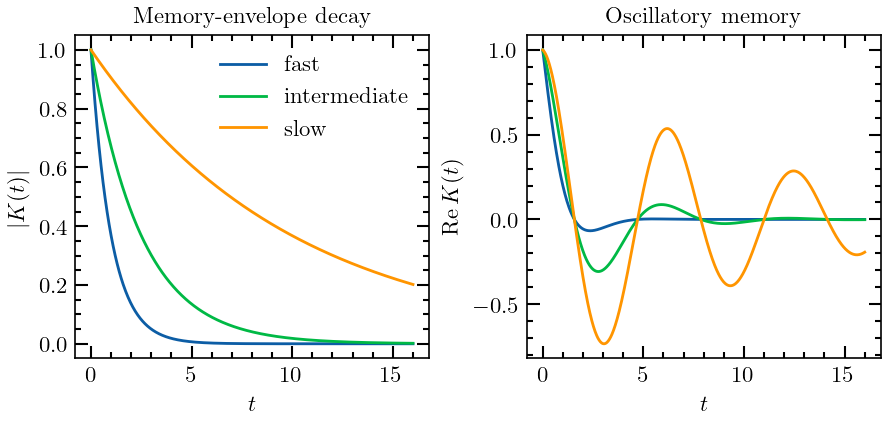

In [12]:
def exponential_memory_kernel(t, delta, kappa):
    return np.exp((1j * delta - 0.5 * kappa) * t) * (t >= 0.0)

memory_t = np.linspace(0.0, 16.0, 801)
memory_cases = {
    "fast": exponential_memory_kernel(memory_t, 1.0, 2.0),
    "intermediate": exponential_memory_kernel(memory_t, 1.0, 0.8),
    "slow": exponential_memory_kernel(memory_t, 1.0, 0.2),
}

memory_rows = []
for label, kernel in memory_cases.items():
    for time, value in zip(memory_t, kernel):
        memory_rows.append({
            "case": label,
            "t": time,
            "abs_kernel": abs(value),
            "real_kernel": np.real(value),
        })

memory_table = pd.DataFrame(memory_rows)
save_table(memory_table, "N07_D12")

fig, axes = plt.subplots(1, 2, figsize=(FIG_WIDTH_150MM, 2.8), constrained_layout=True)

for label, kernel in memory_cases.items():
    axes[0].plot(memory_t, np.abs(kernel), label=label)
    axes[1].plot(memory_t, np.real(kernel), label=label)

axes[0].set(
    xlabel=r"$t$",
    ylabel=r"$|K(t)|$",
    title="Memory-envelope decay",
)
axes[1].set(
    xlabel=r"$t$",
    ylabel=r"$\mathrm{Re}\,K(t)$",
    title="Oscillatory memory",
)
axes[0].legend(frameon=False)

save_figure(fig, "N07_F8")
plt.show()

## 13. Structural failure: a memory-bearing pseudomode

A useful repair of a structured reservoir is to retain an explicit damped
auxiliary mode. Consider a slow bosonic mode $b$ coupled to an auxiliary
pseudomode $c$,

$$
H
=
\Delta_c c^\dagger c
+
g(b^\dagger c+bc^\dagger),
\qquad
L_c=\sqrt{\kappa_c}\,c.
$$

Eliminating $c$ gives the leading time-local slow model

$$
H_{\rm eff}
=
-\frac{g^2\Delta_c}{
\Delta_c^2+\kappa_c^2/4
}
b^\dagger b,
$$

$$
L_{\rm eff}
=
\sqrt{
\frac{g^2\kappa_c}{
\Delta_c^2+\kappa_c^2/4
}
}\;b.
$$

This works when the auxiliary response is fast. When its decay becomes comparable
to the slow dynamics, the explicit pseudomode stores amplitude and phase and the
single-mode Markovian reduction fails.

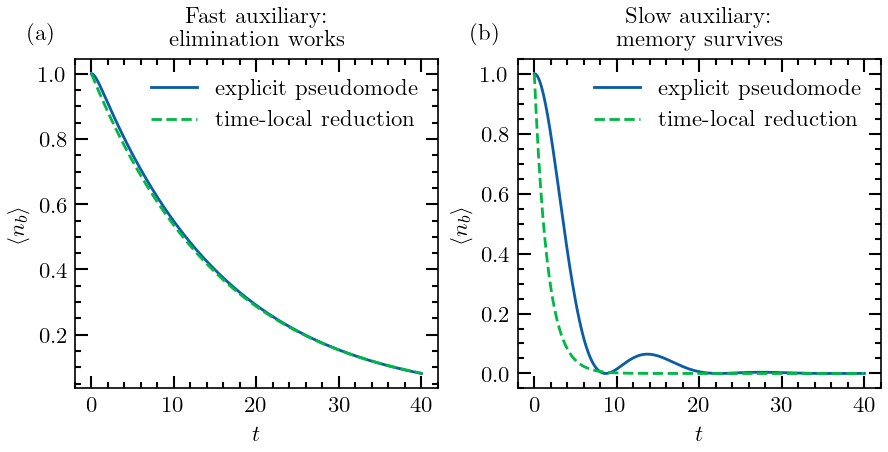

,case,kappa_aux,max_trace_distance,max_auxiliary_population
0,fast auxiliary,4.0,0.027051,0.014091
1,memory-bearing auxiliary,0.4,0.509753,0.363446


In [13]:
def pseudomode_comparison(kappa_aux, detuning_aux=0.0, coupling_aux=0.25):
    cutoff = 2
    b = tensor(destroy(cutoff), qeye(cutoff))
    c = tensor(qeye(cutoff), destroy(cutoff))

    H_full = (
        detuning_aux * c.dag() * c
        + coupling_aux * (b.dag() * c + b * c.dag())
    )
    psi0_full = tensor(basis(cutoff, 1), basis(cutoff, 0))

    times_local = np.linspace(0.0, 40.0, 321)
    out_full = mesolve(
        H_full,
        psi0_full,
        times_local,
        c_ops=[np.sqrt(kappa_aux) * c],
        e_ops=[],
        options=SOLVER,
    )

    reduced_b = [state.ptrace(0) for state in out_full.states]
    mediator_population = np.asarray(
        expect(c.dag() * c, out_full.states),
        dtype=float,
    )

    b_slow = destroy(cutoff)
    den = detuning_aux**2 + (kappa_aux / 2.0)**2
    shift = -coupling_aux**2 * detuning_aux / den
    gamma_eff = coupling_aux**2 * kappa_aux / den

    H_eff = shift * b_slow.dag() * b_slow
    out_eff = mesolve(
        H_eff,
        basis(cutoff, 1),
        times_local,
        c_ops=[np.sqrt(gamma_eff) * b_slow],
        e_ops=[],
        options=SOLVER,
    )
    effective_states = [
        ket2dm(state) if state.isket else state
        for state in out_eff.states
    ]

    error = np.array([
        tracedist(rho, sigma)
        for rho, sigma in zip(reduced_b, effective_states)
    ])
    n_full = np.array([
        expect(b_slow.dag() * b_slow, rho)
        for rho in reduced_b
    ], dtype=float)
    n_eff = np.array([
        expect(b_slow.dag() * b_slow, rho)
        for rho in effective_states
    ], dtype=float)

    return {
        "times": times_local,
        "n_full": n_full,
        "n_eff": n_eff,
        "error": error,
        "mediator_population": mediator_population,
        "gamma_eff": gamma_eff,
    }

memory_fast = pseudomode_comparison(kappa_aux=4.0)
memory_slow = pseudomode_comparison(kappa_aux=0.4)

memory_failure_summary = pd.DataFrame({
    "case": ["fast auxiliary", "memory-bearing auxiliary"],
    "kappa_aux": [4.0, 0.4],
    "max_trace_distance": [
        memory_fast["error"].max(),
        memory_slow["error"].max(),
    ],
    "max_auxiliary_population": [
        memory_fast["mediator_population"].max(),
        memory_slow["mediator_population"].max(),
    ],
})
save_table(memory_failure_summary, "N07_D13")

fig, axes = plt.subplots(1, 2, figsize=(FIG_WIDTH_150MM, 3.0), constrained_layout=True)

axes[0].plot(memory_fast["times"], memory_fast["n_full"], label="explicit pseudomode")
axes[0].plot(memory_fast["times"], memory_fast["n_eff"], "--", label="time-local reduction")
axes[0].set(
    xlabel=r"$t$",
    ylabel=r"$\langle n_b\rangle$",
    title="Fast auxiliary:\nelimination works",
)
axes[0].legend(frameon=False)

axes[1].plot(memory_slow["times"], memory_slow["n_full"], label="explicit pseudomode")
axes[1].plot(memory_slow["times"], memory_slow["n_eff"], "--", label="time-local reduction")
axes[1].set(
    xlabel=r"$t$",
    ylabel=r"$\langle n_b\rangle$",
    title="Slow auxiliary:\nmemory survives",
)
axes[1].legend(frameon=False)

for label, ax in zip("ab", axes):
    panel_label(ax, label)

save_figure(fig, "N07_F9")
plt.show()

memory_failure_summary

The repair is structural. One must retain the pseudomode, retain a larger mode
cluster, or keep a nonlocal memory kernel. Once the auxiliary is no longer fast, higher-order corrections to the same one-mode time-local generator do not restore a uniform timescale separation. The retained space or memory description must change.

## 14. Dictionary among methods and representations

The same fast response appears in different calculational languages. The table
below records the object that each method naturally exposes and the information
that must be carried for a complete physical prediction.

In [14]:
translation_table = pd.DataFrame(
    [
        [
            "Small rotation / normal modes",
            "transformed Hamiltonian",
            "hybridization and dispersive shifts",
            "transformed bath couplings and observables",
        ],
        [
            "Heisenberg-Langevin",
            "operator drift plus input noise",
            "response, spectra, emitted fields",
            "noise correlations and input/output convention",
        ],
        [
            "GKLS master equation",
            "density-operator generator",
            "reduced states and observables",
            "microscopic validity of Hamiltonian and jumps",
        ],
        [
            "Gaussian map",
            "(X,Y) on first and second moments",
            "linear bosonic networks",
            "complete positivity and uncertainty conditions",
        ],
        [
            "Projection / Liouville resolvent",
            "(z-Q L Q)^(-1)",
            "slow poles and elimination",
            "retained space, fast gap, memory scale",
        ],
        [
            "Dissipative Schrieffer-Wolff",
            "block-diagonal Liouvillian",
            "systematic slow generator",
            "dressed jumps and inverse transformation",
        ],
        [
            "Magnus / James-Jerke",
            "averaged or filtered generator",
            "periodic/coarse-grained dynamics",
            "noise harmonics, boundary terms, reconstruction",
        ],
        [
            "Floquet",
            "quasienergy generator",
            "periodically driven systems",
            "micromotion and periodically transformed bath/output fields",
        ],
        [
            "Input-output theory",
            "incoming and outgoing fields",
            "experimentally measured radiation",
            "port phases, normalization, and bath state",
        ],
    ],
    columns=[
        "description",
        "natural_object",
        "best_suited_to",
        "information_that_must_be_carried",
    ],
)
save_table(translation_table, "N07_D14")
translation_table

,description,natural_object,best_suited_to,information_that_must_be_carried
0,Small rotation / normal modes,transformed Hamiltonian,hybridization and dispersive shifts,transformed bath couplings and observables
1,Heisenberg-Langevin,operator drift plus input noise,"response, spectra, emitted fields",noise correlations and input/output convention
2,GKLS master equation,density-operator generator,reduced states and observables,microscopic validity of Hamiltonian and jumps
3,Gaussian map,"(X,Y) on first and second moments",linear bosonic networks,complete positivity and uncertainty conditions
4,Projection / Liouville resolvent,(z-Q L Q)^(-1),slow poles and elimination,"retained space, fast gap, memory scale"
5,Dissipative Schrieffer-Wolff,block-diagonal Liouvillian,systematic slow generator,dressed jumps and inverse transformation
6,Magnus / James-Jerke,averaged or filtered generator,periodic/coarse-grained dynamics,"noise harmonics, boundary terms, reconstruction"
7,Floquet,quasienergy generator,periodically driven systems,micromotion and periodically transformed bath/...
8,Input-output theory,incoming and outgoing fields,experimentally measured radiation,"port phases, normalization, and bath state"


## 15. Contrasting eliminated subsystem: a fast dissipative spin

Eliminating a fast lossy **spin** is not identical to eliminating a harmonic
mediator. A dissipative Rabi-type auxiliary can produce a quadratic oscillator
Hamiltonian and a Hermitian quadrature jump,

$$
H_{\rm eff}\supset\chi_X X^2,
\qquad
\mathcal L_{\rm eff}\supset\Gamma_X\mathcal D[X],
\qquad
X=a+a^\dagger.
$$

This is useful as a contrast:

- a lossy bosonic mediator can generate collective target loss and coherent
  exchange;
- a lossy spin can generate oscillator renormalization and quadrature-selective
  diffusion.

In both cases, reactive and fluctuating parts of the fast response must be kept
together. A Hermitian quadrature jump should not automatically be described as a
squeezed thermal reservoir without an explicit covariance analysis.

## 16. Liouville-space vectorization

We use **column stacking**,

$$
|X\rangle\rangle=\operatorname{vec}(X),
$$

with

$$
\operatorname{vec}(AXB)
=
(B^T\otimes A)\operatorname{vec}(X).
$$

For a Hamiltonian contribution,

$$
\mathbb L_H
=
-i(I\otimes H-H^T\otimes I).
$$

Changing the vectorization convention changes the matrix representation but not
the physical superoperator. N07 therefore checks the convention directly against
QuTiP's `operator_to_vector` and `liouvillian`.

In [15]:
h_qubit = 0.5 * 1.3 * sigmaz()
gamma_qubit = 0.4

L_qubit = liouvillian(
    h_qubit,
    [np.sqrt(gamma_qubit) * sigmam()],
)

rho_test = Qobj(
    [[0.3, 0.2j], [-0.2j, 0.7]],
    dims=[[2], [2]],
)

vec_rho = operator_to_vector(rho_test)
left = L_qubit * vec_rho

manual_rhs = (
    -1j * (h_qubit * rho_test - rho_test * h_qubit)
    + gamma_qubit * (
        sigmam() * rho_test * sigmap()
        - 0.5 * (
            sigmap() * sigmam() * rho_test
            + rho_test * sigmap() * sigmam()
        )
    )
)
right = operator_to_vector(manual_rhs)

vectorization_residual = (left - right).norm()

vectorization_table = pd.DataFrame({
    "quantity": ["vectorization_residual"],
    "value": [vectorization_residual],
})
save_table(vectorization_table, "N07_D15")

print(f"vectorization residual: {vectorization_residual:.3e}")

vectorization residual: 0.000e+00


## 17. Finite-time maps and Choi operators

A time-independent Liouvillian generates

$$
\Phi_t=e^{t\mathcal L}.
$$

For a physical finite-time quantum channel, the Choi operator

$$
C_{\Phi_t}
=
(\Phi_t\otimes I)
\left(
|\Omega\rangle\langle\Omega|
\right)
$$

must be positive semidefinite. This is a map-level physicality test.

A finite-time map can be physical while still being quantitatively inaccurate
for the microscopic model. Conversely, a trace-preserving approximation can fail
complete positivity. **Physicality and accuracy are separate questions.**

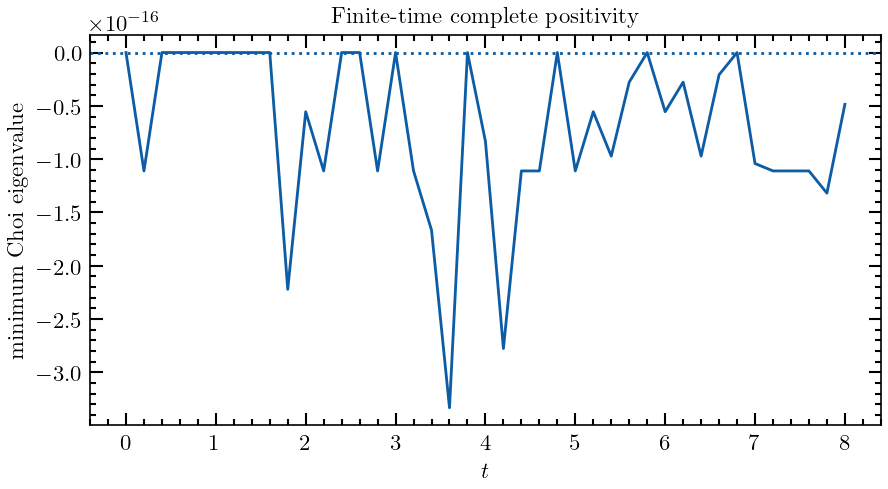

In [16]:
choi_times = np.linspace(0.0, 8.0, 41)
choi_rows = []

for time in choi_times:
    channel = (L_qubit * time).expm()
    choi = to_choi(channel)
    eigenvalues = np.real(choi.eigenenergies())

    choi_rows.append({
        "t": time,
        "minimum_choi_eigenvalue": np.min(eigenvalues),
        "choi_trace": np.real(choi.tr()),
    })

choi_table = pd.DataFrame(choi_rows)
save_table(choi_table, "N07_D16")

fig, ax = plt.subplots(figsize=(FIG_WIDTH_150MM, 3.25), constrained_layout=True)
ax.plot(choi_table["t"], choi_table["minimum_choi_eigenvalue"])
ax.axhline(0.0, linestyle=":", linewidth=CURVE_LINEWIDTH)
ax.set(
    xlabel=r"$t$",
    ylabel="minimum Choi eigenvalue",
    title="Finite-time complete positivity",
)
save_figure(fig, "N07_F10")
plt.show()

## 18. Steady states and Liouvillian gaps

The steady state satisfies

$$
\mathcal L|\rho_{\rm ss}\rangle\rangle=0.
$$

The nonzero Liouvillian eigenvalue with the smallest magnitude of negative real
part sets the slowest exponential relaxation scale when the spectrum is simple.

A steady-state comparison alone can be misleading: two models can be forced into
the same trivial steady state while having very different transient dynamics.
The claim and the validation observable must therefore be matched.

In [17]:
rho_ss = steadystate(
    h_qubit,
    [np.sqrt(gamma_qubit) * sigmam()],
)

L_eigs = np.asarray(L_qubit.eigenenergies(), dtype=complex)
decaying = [
    value
    for value in L_eigs
    if np.real(value) < -1e-12
]
liouvillian_gap = min(-np.real(value) for value in decaying)

steady_state_table = pd.DataFrame({
    "quantity": [
        "steady_state_trace",
        "steady_state_excited_population",
        "liouvillian_gap",
    ],
    "value": [
        np.real(rho_ss.tr()),
        np.real(expect(sigmap() * sigmam(), rho_ss)),
        liouvillian_gap,
    ],
})
save_table(steady_state_table, "N07_D17")
steady_state_table

,quantity,value
0,steady_state_trace,1.0
1,steady_state_excited_population,0.0
2,liouvillian_gap,0.2


## 19. Validation ledger

The notebook now contains several logically distinct tests:

- representation equivalence: Gaussian channel versus QuTiP master equation;
- numerical-reference convergence: Fock cutoff;
- state physicality: covariance uncertainty condition;
- map physicality: Gaussian CP condition and Choi positivity;
- convention consistency: Liouville vectorization;
- structural validity: fast-pseudomode elimination versus a memory-bearing
  pseudomode;
- experimental reconstruction: output flux from the input-output relation.

Passing one test does not imply the others.

In [18]:
validation = pd.DataFrame({
    "check": [
        "stable Gaussian drift",
        "Gaussian/master benchmark agreement",
        "N=8 cutoff close to N=10",
        "state uncertainty condition",
        "Gaussian-channel CP condition",
        "noise restores commutator",
        "driven-cavity first moments agree",
        "driven-cavity occupation agrees",
        "Liouville vectorization convention",
        "finite-time Choi positivity",
        "Choi trace equals Hilbert dimension",
        "fast pseudomode better than memory-bearing elimination",
        "memory-bearing pseudomode significantly populated",
        "output flux nonnegative",
    ],
    "value": [
        drift_stability,
        gaussian_master_error,
        cutoff_table.loc[cutoff_table["cutoff"] == 8, "max_error_to_N10"].iloc[0],
        gaussian_cp_table["minimum_uncertainty_eigenvalue"].min(),
        gaussian_cp_table["minimum_gaussian_cp_eigenvalue"].min(),
        np.max(np.abs(comm_complete - 1.0)),
        first_moment_error,
        occupation_error,
        vectorization_residual,
        choi_table["minimum_choi_eigenvalue"].min(),
        np.max(np.abs(choi_table["choi_trace"] - 2.0)),
        memory_slow["error"].max() - memory_fast["error"].max(),
        memory_slow["mediator_population"].max(),
        output_flux.min(),
    ],
})
save_table(validation, "N07_D18")

assert drift_stability < 0.0
assert gaussian_master_error < 1e-3
assert cutoff_table.loc[
    cutoff_table["cutoff"] == 8,
    "max_error_to_N10",
].iloc[0] < 5e-4
assert gaussian_cp_table["minimum_uncertainty_eigenvalue"].min() > -1e-9
assert gaussian_cp_table["minimum_gaussian_cp_eigenvalue"].min() > -1e-9
assert np.max(np.abs(comm_complete - 1.0)) < 1e-12
assert first_moment_error < 2e-4
assert occupation_error < 2e-4
assert vectorization_residual < 1e-12
assert choi_table["minimum_choi_eigenvalue"].min() > -1e-10
assert np.max(np.abs(choi_table["choi_trace"] - 2.0)) < 1e-10
assert memory_fast["error"].max() < memory_slow["error"].max()
assert memory_slow["mediator_population"].max() > 0.05
assert output_flux.min() > -1e-12

validation

,check,value
0,stable Gaussian drift,-4.348208e-02
1,Gaussian/master benchmark agreement,2.910873e-05
2,N=8 cutoff close to N=10,2.867593e-05
3,state uncertainty condition,-5.828671e-16
4,Gaussian-channel CP condition,-6.543435e-16
5,noise restores commutator,0.000000e+00
6,driven-cavity first moments agree,9.061600e-08
7,driven-cavity occupation agrees,6.473267e-08
8,Liouville vectorization convention,0.000000e+00
9,finite-time Choi positivity,-3.330669e-16


## 20. Scope, failure modes, and structural repair

The direct equivalence between a white-noise Langevin equation and a time-local
GKLS master equation relies on a common Markovian system-bath reduction.
Additional care is required for:

- structured or colored reservoirs;
- strong system-bath coupling;
- initial system-environment correlations;
- nonlinear operator hierarchies that do not close;
- frequency-dependent bath spectra;
- time-nonlocal or non-GKLS reduced equations;
- driven systems in which the bath coupling must be transformed together with
  the Hamiltonian.

The first structural repair is determined by the missing physics. A resonant
hybrid mode should be retained. A narrow structured reservoir may be represented
by a pseudomode or reaction coordinate. A driven system may require transformed
noise and output operators. A nonlinear hierarchy may require a larger moment
closure or full Hilbert-space evolution.

## 21. Adapting the workflow to a related model

For another open-system problem, use the following sequence.

1. Identify the physical observable: reduced state, spectrum, emitted field,
   covariance, channel, or steady state.
2. Write the microscopic system-bath coupling and fix the dissipator and
   input-output conventions.
3. Determine the slow/fast split and the relevant spectral or Liouvillian gap.
4. If the model is linear, build the drift and diffusion matrices and the
   finite-time Gaussian map.
5. Build an independent QuTiP master-equation reference whenever the Hilbert
   space is tractable.
6. Carry the noise and output operators through every frame or elimination.
7. Test physicality and accuracy separately.
8. Compare over a declared time window and converge the numerical reference.
9. If the bath correlation time becomes long, retain the responsible mode or
   memory kernel rather than forcing a white-noise model.
10. Save claim-matched observables rather than relying on one abstract error
    norm.

The transferable principle is that a complete open-system prediction consists
of a deterministic response **plus** the fluctuations, encoding, map, and
observable reconstruction required by the physical question.

## 22. Exercises and research extensions

1. Derive the two-mode drift matrix directly from the Heisenberg equations.
2. Transform the collapse operators under the small normal-mode rotation and
   identify cross-damping terms.
3. Show analytically that vacuum input noise restores
   $[a(t),a^\dagger(t)]=1$.
4. Derive the thermal occupation law
   $$
   n(t)=n(0)e^{-\kappa t}+\bar n(1-e^{-\kappa t}).
   $$
5. Derive the stationary covariance from
   $AV_\infty+V_\infty A^T+D=0$.
6. Derive the Gaussian complete-positivity condition used in Section 8.
7. Replace the coherent initial state by a squeezed Gaussian state and verify
   Gaussian/master-equation agreement.
8. Derive the input-output relation from a flat bath continuum.
9. Compute the emitted spectrum rather than only the instantaneous photon flux.
10. Derive frequency-resolved effective jumps for a slow operator with two
    distinct Bohr frequencies.
11. Transform both a Hamiltonian and its bath coupling with a time-dependent
    Schrieffer-Wolff or Floquet unitary.
12. Replace the Markovian bath by a Lorentzian structured reservoir and compare
    an explicit pseudomode model with a nonlocal memory kernel.
13. Increase the pseudomode coupling until the time-local elimination fails and
    compare that failure point with the local ratio of coupling to the complex
    fast gap.
14. Add thermal occupation to the pseudomode bath and derive the corresponding
    upward and downward effective channels.
15. Construct a trace-preserving but non-CP approximate generator and determine
    when its finite-time Choi operator first develops a negative eigenvalue.

## References

1. C. W. Gardiner and M. J. Collett, “Input and output in damped quantum
   systems: Quantum stochastic differential equations and the master equation,”
   *Phys. Rev. A* **31**, 3761 (1985).
2. C. W. Gardiner and P. Zoller, *Quantum Noise*.
3. H. J. Carmichael, *Statistical Methods in Quantum Optics*.
4. A. S. Holevo and R. F. Werner, “Evaluating capacities of bosonic Gaussian
   channels,” *Phys. Rev. A* **63**, 032312 (2001).
5. F. Reiter and A. S. Sørensen, “Effective operator formalism for open quantum
   systems,” *Phys. Rev. A* **85**, 032111 (2012).
6. E. M. Kessler, “Generalized Schrieffer-Wolff formalism for dissipative
   systems,” *Phys. Rev. A* **86**, 012126 (2012).
7. S. B. Jäger, T. Schmit, G. Morigi, M. J. Holland, and R. Betzholz,
   “Lindblad master equations for quantum systems coupled to dissipative bosonic
   modes,” *Phys. Rev. Lett.* **129**, 063601 (2022).
8. L. Mazzola, S. Maniscalco, J. Piilo, K.-A. Suominen, and B. M. Garraway,
   “Pseudomodes as an effective description of memory,”
   *Phys. Rev. A* **80**, 012104 (2009).
9. G. Pleasance, B. M. Garraway, and F. Petruccione,
   “Generalized theory of pseudomodes for exact descriptions of non-Markovian
   quantum processes,” *Phys. Rev. Research* **2**, 043058 (2020).
10. N. Lambert *et al.*, “QuTiP 5: The Quantum Toolbox in Python,”
    *Physics Reports* **1153**, 1-62 (2026).

In [19]:
environment = {
    "python": sys.version,
    "qutip": qt.__version__,
    "numpy": np.__version__,
    "scipy": __import__("scipy").__version__,
    "pandas": pd.__version__,
    "matplotlib": plt.matplotlib.__version__,
    "scienceplots": getattr(scienceplots, "__version__", "installed"),
    "platform": platform.platform(),
    "notebook": "N07",
}
(DATA_DIR / "N07_environment.json").write_text(
    json.dumps(environment, indent=2),
    encoding="utf-8",
)
environment

{'python': '3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]',
 'qutip': '5.2.0',
 'numpy': '2.3.2',
 'scipy': '1.16.1',
 'pandas': '3.0.6',
 'matplotlib': '3.10.5',
 'scienceplots': 'installed',
 'platform': 'Windows-10-10.0.26200-SP0',
 'notebook': 'N07'}